## EXPLORATORY DATA ANALYSIS

## Import Library dan Konfigurasi Lingkungan Analisis

### Deskripsi
Cell ini digunakan untuk mengimpor seluruh library utama yang diperlukan selama proses analisis data, visualisasi, dan pemodelan. Selain itu, dilakukan konfigurasi awal untuk mengatur tampilan visualisasi serta menyembunyikan pesan peringatan (*warning*) yang tidak memengaruhi hasil analisis sehingga output notebook menjadi lebih bersih dan mudah dibaca.

### Tujuan
- Mengimpor library yang diperlukan untuk analisis data, yaitu:
  - **Pandas** untuk manipulasi dan pengolahan data.
  - **NumPy** untuk komputasi numerik dan operasi matematis.
  - **Matplotlib** untuk membuat visualisasi data.
  - **Seaborn** untuk menghasilkan visualisasi statistik yang lebih informatif dan estetis.
- Menonaktifkan tampilan *warning* agar output notebook lebih rapi.
- Mengatur gaya visualisasi menggunakan tema **whitegrid**.
- Menentukan ukuran default gambar (`8 × 5`) dan ukuran font (`11`) sehingga seluruh grafik memiliki tampilan yang konsisten.

In [34]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

## Memuat Dataset

### Deskripsi
Cell ini digunakan untuk menentukan lokasi penyimpanan dataset dan memuat data ke dalam DataFrame menggunakan **Pandas**. Dataset yang digunakan adalah **Churn_Modelling.csv**, yang berisi informasi karakteristik pelanggan beserta status churn (keluar atau tetap menjadi pelanggan).

### Tujuan
- Menentukan lokasi file dataset yang akan digunakan dalam proses analisis.
- Membaca file berformat **CSV** menggunakan fungsi `pd.read_csv()`.
- Menyimpan data ke dalam DataFrame `df` sebagai objek utama yang akan digunakan pada tahap eksplorasi data, prapemrosesan, hingga pemodelan machine learning.

In [35]:
path = r"C:\kuliah\tubes STD & Algo\Churn_Modelling.csv"

df = pd.read_csv(path)

## Feature Engineering

### Deskripsi
Cell ini mendefinisikan kelas **FeatureEngineering** yang bertujuan untuk menghasilkan fitur-fitur baru berdasarkan informasi yang telah tersedia pada dataset. Feature engineering dilakukan dengan menghitung **churn rate** pada beberapa kelompok pelanggan, seperti negara, jenis kelamin, status keaktifan, kepemilikan kartu kredit, dan jumlah produk yang dimiliki. Selain itu, dibuat pula label kategorikal untuk mempermudah interpretasi target.

### Tujuan
- Membuat label target yang lebih mudah dipahami, yaitu **Churn** dan **Non-Churn**.
- Menghasilkan fitur **Country_Churn_Rate** dan **Country_NonChurn_Rate** berdasarkan rata-rata churn pada setiap negara.
- Menghasilkan fitur **Gender_Churn_Rate** berdasarkan rata-rata churn pada setiap jenis kelamin.
- Menghasilkan fitur **Active_Churn_Rate** berdasarkan tingkat churn pelanggan aktif dan tidak aktif.
- Menghasilkan fitur **Card_Churn_Rate** berdasarkan tingkat churn pelanggan yang memiliki atau tidak memiliki kartu kredit.
- Menghasilkan fitur **Product_Churn_Rate** berdasarkan tingkat churn pada setiap jumlah produk yang dimiliki pelanggan.
- Menggabungkan seluruh fitur hasil rekayasa ke dalam dataset sehingga dapat digunakan pada tahap analisis maupun pemodelan berikutnya.

In [36]:
class FeatureEngineering:

    def __init__(self, df):
        self.df = df.copy()

    def run(self):

        self.df["Churn_Label"] = self.df["Exited"].map({
            0:"Non-Churn",
            1:"Churn"
        })

        # Country
        country = (
            self.df.groupby("Geography")["Exited"]
            .mean()
            .reset_index()
        )

        country.columns = [
            "Geography",
            "Country_Churn_Rate"
        ]

        self.df = self.df.merge(country,on="Geography")

        self.df["Country_NonChurn_Rate"] = (
            1-self.df["Country_Churn_Rate"]
        )

        # Gender

        gender = (
            self.df.groupby("Gender")["Exited"]
            .mean()
            .reset_index()
        )

        gender.columns=[
            "Gender",
            "Gender_Churn_Rate"
        ]

        self.df=self.df.merge(gender,on="Gender")

        # Active

        active=(
            self.df.groupby("IsActiveMember")["Exited"]
            .mean()
            .reset_index()
        )

        active.columns=[
            "IsActiveMember",
            "Active_Churn_Rate"
        ]

        self.df=self.df.merge(active,on="IsActiveMember")

        # Card

        card=(
            self.df.groupby("HasCrCard")["Exited"]
            .mean()
            .reset_index()
        )

        card.columns=[
            "HasCrCard",
            "Card_Churn_Rate"
        ]

        self.df=self.df.merge(card,on="HasCrCard")

        # Product

        product=(
            self.df.groupby("NumOfProducts")["Exited"]
            .mean()
            .reset_index()
        )

        product.columns=[
            "NumOfProducts",
            "Product_Churn_Rate"
        ]

        self.df=self.df.merge(product,on="NumOfProducts")

        return self.df

## Menerapkan Feature Engineering

### Deskripsi
Cell ini digunakan untuk menginisialisasi kelas **FeatureEngineering** dengan dataset yang telah dimuat, kemudian menjalankan proses rekayasa fitur menggunakan metode `run()`. Hasil dari proses tersebut disimpan kembali ke dalam DataFrame `df`, sehingga dataset kini telah memiliki fitur-fitur baru yang akan digunakan pada tahapan analisis selanjutnya. Terakhir, ditampilkan lima baris pertama dataset untuk memastikan bahwa proses feature engineering telah berhasil dilakukan.

### Tujuan
- Membuat objek dari kelas **FeatureEngineering**.
- Menjalankan seluruh proses rekayasa fitur pada dataset.
- Memperbarui DataFrame dengan fitur-fitur hasil feature engineering.
- Memverifikasi hasil penambahan fitur melalui tampilan lima baris pertama dataset menggunakan `df.head()`.

In [37]:
fe = FeatureEngineering(df)

df = fe.run()

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,IsActiveMember,EstimatedSalary,Exited,Churn_Label,Country_Churn_Rate,Country_NonChurn_Rate,Gender_Churn_Rate,Active_Churn_Rate,Card_Churn_Rate,Product_Churn_Rate
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,1,101348.88,1,Churn,0.161548,0.838452,0.250715,0.142691,0.201843,0.277144
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,1,112542.58,0,Non-Churn,0.166734,0.833266,0.250715,0.142691,0.208149,0.277144
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,0,113931.57,1,Churn,0.161548,0.838452,0.250715,0.268509,0.201843,0.827068
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,0,93826.63,0,Non-Churn,0.161548,0.838452,0.250715,0.268509,0.208149,0.075817
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,1,79084.10,0,Non-Churn,0.166734,0.833266,0.250715,0.142691,0.201843,0.277144


## Mendefinisikan Kelas Exploratory Data Analysis (EDA)

### Deskripsi
Cell ini mendefinisikan kelas **EDAAnalysis** yang berisi sekumpulan fungsi untuk melakukan **Exploratory Data Analysis (EDA)** terhadap dataset. Kelas ini dirancang agar proses eksplorasi data menjadi lebih terstruktur dan dapat digunakan kembali tanpa perlu menulis ulang kode pada setiap analisis.

Metode-metode yang tersedia mencakup pemeriksaan struktur dataset, identifikasi nilai yang hilang (*missing value*), analisis statistik deskriptif, ringkasan distribusi pelanggan berdasarkan status churn, serta pembuatan tabel ringkasan untuk setiap variabel kategorikal.

### Tujuan
- Menyediakan fungsi untuk menampilkan ukuran dataset (*shape*), informasi kolom (*info*), dan tipe data setiap variabel.
- Mengidentifikasi jumlah dan persentase *missing value* pada setiap fitur.
- Menampilkan statistik deskriptif untuk seluruh variabel numerik.
- Menyajikan ringkasan jumlah pelanggan, jumlah churn, jumlah non-churn, serta persentase masing-masing.
- Membuat tabel ringkasan berdasarkan variabel tertentu yang memuat total pelanggan, total churn, total non-churn, churn rate, dan non-churn rate.
- Membuat proses EDA menjadi lebih sistematis, modular, dan mudah digunakan kembali pada notebook maupun proyek lainnya.

In [38]:
class EDAAnalysis:

    def __init__(self,df):

        self.df=df

    def dataset_info(self):

        print("="*60)
        print("SHAPE")
        print("="*60)
        print(self.df.shape)

        print()

        print("="*60)
        print("INFO")
        print("="*60)
        print(self.df.info())

        print()

        print("="*60)
        print("DTYPES")
        print("="*60)
        print(self.df.dtypes)

    def missing_value(self):

        missing=pd.DataFrame({

            "Missing Value":self.df.isnull().sum(),
            "Percentage (%)":round(
                self.df.isnull().mean()*100,2
            )

        })

        display(missing)

    def descriptive(self):

        display(self.df.describe().T)

    def churn_summary(self):

        total=len(self.df)

        churn=self.df["Exited"].sum()

        non=total-churn

        print(f"Total Customer : {total}")
        print(f"Total Churn : {churn}")
        print(f"Total Non Churn : {non}")
        print(f"Churn Rate : {churn/total:.2%}")
        print(f"Non Churn Rate : {non/total:.2%}")

    def summary_table(self,column):

        summary=(
            self.df.groupby(column)
            .agg(
                Total_Customer=("Exited","count"),
                Total_Churn=("Exited","sum")
            )
            .reset_index()
        )

        summary["Total_NonChurn"]=(
            summary["Total_Customer"]-
            summary["Total_Churn"]
        )

        summary["Churn_Rate"]=(
            summary["Total_Churn"]/
            summary["Total_Customer"]
        )

        summary["NonChurn_Rate"]=(
            summary["Total_NonChurn"]/
            summary["Total_Customer"]
        )

        display(summary)

        return summary

## Mendefinisikan Kelas Visualisasi Data

### Deskripsi
Cell ini mendefinisikan kelas **Visualization** yang berisi berbagai fungsi untuk membuat visualisasi pada dataset pelanggan. Visualisasi digunakan sebagai bagian dari **Exploratory Data Analysis (EDA)** guna memahami distribusi data, pola hubungan antarvariabel, serta karakteristik pelanggan yang melakukan churn maupun tidak.

Berbagai jenis grafik yang disediakan meliputi diagram lingkaran (*pie chart*), diagram batang (*bar chart*), histogram, boxplot, heatmap korelasi, hingga pairplot. Seluruh visualisasi dibuat dalam satu kelas sehingga proses analisis menjadi lebih terstruktur dan mudah digunakan kembali.

### Tujuan
- Menyediakan visualisasi proporsi pelanggan **churn** dan **non-churn** secara keseluruhan menggunakan *pie chart*.
- Menampilkan perbandingan **churn rate** berdasarkan negara (*Geography*) dan jenis kelamin (*Gender*).
- Memvisualisasikan pengaruh status pelanggan aktif (*IsActiveMember*) dan kepemilikan kartu kredit (*HasCrCard*) terhadap tingkat churn menggunakan *bar chart*.
- Menampilkan distribusi setiap variabel numerik menggunakan histogram dan *kernel density estimation (KDE)*.
- Membandingkan distribusi variabel numerik antara pelanggan **churn** dan **non-churn** melalui histogram berdasarkan kelas target.
- Mengidentifikasi perbedaan sebaran data dan potensi *outlier* menggunakan boxplot.
- Menganalisis hubungan antarvariabel numerik serta variabel target menggunakan heatmap korelasi dan *triangle heatmap*.
- Memvisualisasikan hubungan antarfitur numerik secara simultan menggunakan *pairplot* untuk membantu mengidentifikasi pola, klaster, maupun potensi pemisahan antar kelas.

In [39]:
class Visualization:

    def __init__(self,df):

        self.df=df

        self.numeric=[
            "CreditScore",
            "Age",
            "Tenure",
            "Balance",
            "NumOfProducts",
            "EstimatedSalary"
        ]

    def overall_pie(self):

        total=self.df["Exited"].value_counts()

        plt.figure(figsize=(6,6))

        plt.pie(
            total,
            labels=["Non-Churn","Churn"],
            autopct="%1.2f%%",
            startangle=90
        )

        plt.title("Overall Churn Rate")
        plt.show()

    def pie_country(self):

        summary=(
            self.df.groupby("Geography")["Exited"]
            .mean()
        )

        plt.figure(figsize=(6,6))

        plt.pie(
            summary,
            labels=summary.index,
            autopct="%1.2f%%"
        )

        plt.title("Country Churn Rate")

        plt.show()

    def pie_gender(self):

        summary=(
            self.df.groupby("Gender")["Exited"]
            .mean()
        )

        plt.figure(figsize=(6,6))

        plt.pie(
            summary,
            labels=summary.index,
            autopct="%1.2f%%"
        )

        plt.title("Gender Churn Rate")

        plt.show()

    def bar_active(self):

        sns.barplot(
            data=self.df,
            x="IsActiveMember",
            y="Exited"
        )

        plt.title("Active Member")
        plt.show()

    def bar_card(self):

        sns.barplot(
            data=self.df,
            x="HasCrCard",
            y="Exited"
        )

        plt.title("Credit Card")
        plt.show()

    def distribution(self):

        for col in self.numeric:

            plt.figure(figsize=(8,4))

            sns.histplot(
                self.df[col],
                kde=True,
                bins=30
            )

            plt.title(col)

            plt.show()

    def distribution_churn(self):

        for col in self.numeric:

            plt.figure(figsize=(8,4))

            sns.histplot(
                data=self.df,
                x=col,
                hue="Churn_Label",
                kde=True
            )

            plt.title(col)

            plt.show()

    def boxplot(self):

        for col in self.numeric:

            plt.figure(figsize=(7,4))

            sns.boxplot(
                data=self.df,
                x="Churn_Label",
                y=col
            )

            plt.title(col)

            plt.show()

    def heatmap(self):

        corr=self.df[self.numeric+["Exited"]].corr()

        plt.figure(figsize=(10,8))

        sns.heatmap(
            corr,
            annot=True,
            cmap="RdBu_r"
        )

        plt.title("Correlation Heatmap")

        plt.show()

    def triangle_heatmap(self):

        corr=self.df[self.numeric+["Exited"]].corr()

        mask=np.triu(np.ones_like(corr,dtype=bool))

        plt.figure(figsize=(10,8))

        sns.heatmap(
            corr,
            mask=mask,
            annot=True,
            cmap="coolwarm"
        )

        plt.title("Triangle Heatmap")

        plt.show()

    def pairplot(self):

        sns.pairplot(
            self.df[
                [
                    "CreditScore",
                    "Age",
                    "Balance",
                    "EstimatedSalary",
                    "Exited"
                ]
            ],
            hue="Exited",
            diag_kind="kde"
        )

        plt.show()

## Menjalankan Exploratory Data Analysis (EDA) dan Visualisasi

### Deskripsi
Cell ini merupakan bagian utama (*main program*) yang digunakan untuk menjalankan seluruh proses **Exploratory Data Analysis (EDA)** dan visualisasi yang telah didefinisikan sebelumnya. Program diawali dengan membuat objek dari kelas **EDAAnalysis**, kemudian menjalankan seluruh fungsi analisis secara berurutan menggunakan sebuah daftar (*list*) dan perulangan (*loop*). Setelah seluruh analisis selesai dilakukan, program membuat objek dari kelas **Visualization** untuk menghasilkan berbagai grafik yang digunakan dalam eksplorasi data.

Pendekatan ini membuat alur analisis menjadi lebih terstruktur, ringkas, dan mudah dipelihara karena setiap fungsi dipanggil secara otomatis tanpa perlu dituliskan satu per satu.

### Tujuan
- Menginisialisasi objek **EDAAnalysis** menggunakan dataset yang telah diproses.
- Menjalankan seluruh proses eksplorasi data, meliputi:
  - Informasi umum dataset.
  - Pemeriksaan *missing value*.
  - Statistik deskriptif.
  - Ringkasan jumlah pelanggan berdasarkan status churn.
  - Tabel ringkasan churn berdasarkan negara, jenis kelamin, status keaktifan, kepemilikan kartu kredit, dan jumlah produk.
- Menginisialisasi objek **Visualization**.
- Menampilkan seluruh visualisasi EDA secara otomatis, meliputi:
  - Diagram proporsi churn.
  - Visualisasi churn berdasarkan negara dan jenis kelamin.
  - Diagram batang status pelanggan aktif dan kepemilikan kartu kredit.
  - Histogram distribusi variabel numerik.
  - Histogram berdasarkan status churn.
  - Boxplot.
  - Heatmap korelasi.
  - Triangle heatmap.
  - Pairplot.
- Mengotomatisasi seluruh proses EDA sehingga analisis dapat dijalankan secara sistematis hanya dengan mengeksekusi satu cell.

SHAPE
(10000, 21)

INFO
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RowNumber              10000 non-null  int64  
 1   CustomerId             10000 non-null  int64  
 2   Surname                10000 non-null  str    
 3   CreditScore            10000 non-null  int64  
 4   Geography              10000 non-null  str    
 5   Gender                 10000 non-null  str    
 6   Age                    10000 non-null  int64  
 7   Tenure                 10000 non-null  int64  
 8   Balance                10000 non-null  float64
 9   NumOfProducts          10000 non-null  int64  
 10  HasCrCard              10000 non-null  int64  
 11  IsActiveMember         10000 non-null  int64  
 12  EstimatedSalary        10000 non-null  float64
 13  Exited                 10000 non-null  int64  
 14  Churn_Label            10000 non-null  str

,Missing Value,Percentage (%)
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.000000e+00,2.500750e+03,5.000500e+03,7.500250e+03,1.000000e+04
CustomerId,10000.0,1.569094e+07,71936.186123,1.556570e+07,1.562853e+07,1.569074e+07,1.575323e+07,1.581569e+07
CreditScore,10000.0,6.505288e+02,96.653299,3.500000e+02,5.840000e+02,6.520000e+02,7.180000e+02,8.500000e+02
Age,10000.0,3.892180e+01,10.487806,1.800000e+01,3.200000e+01,3.700000e+01,4.400000e+01,9.200000e+01
Tenure,10000.0,5.012800e+00,2.892174,0.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,1.000000e+01
Balance,10000.0,7.648589e+04,62397.405202,0.000000e+00,0.000000e+00,9.719854e+04,1.276442e+05,2.508981e+05
NumOfProducts,10000.0,1.530200e+00,0.581654,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00
HasCrCard,10000.0,7.055000e-01,0.455840,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,1.158000e+01,5.100211e+04,1.001939e+05,1.493882e+05,1.999925e+05


Total Customer : 10000
Total Churn : 2037
Total Non Churn : 7963
Churn Rate : 20.37%
Non Churn Rate : 79.63%


,Geography,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,France,5014,810,4204,0.161548,0.838452
1,Germany,2509,814,1695,0.324432,0.675568
2,Spain,2477,413,2064,0.166734,0.833266


,Gender,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,Female,4543,1139,3404,0.250715,0.749285
1,Male,5457,898,4559,0.164559,0.835441


,IsActiveMember,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,0,4849,1302,3547,0.268509,0.731491
1,1,5151,735,4416,0.142691,0.857309


,HasCrCard,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,0,2945,613,2332,0.208149,0.791851
1,1,7055,1424,5631,0.201843,0.798157


,NumOfProducts,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,1,5084,1409,3675,0.277144,0.722856
1,2,4590,348,4242,0.075817,0.924183
2,3,266,220,46,0.827068,0.172932
3,4,60,60,0,1.000000,0.000000


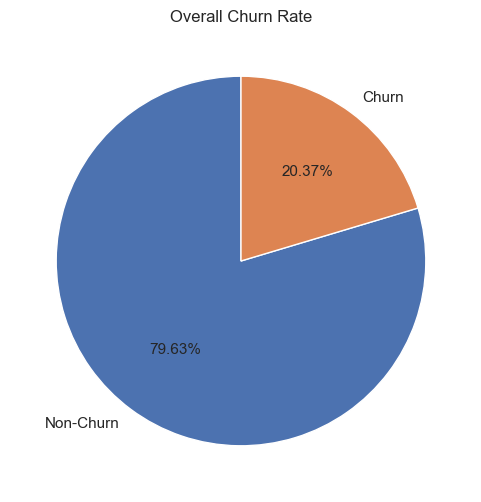

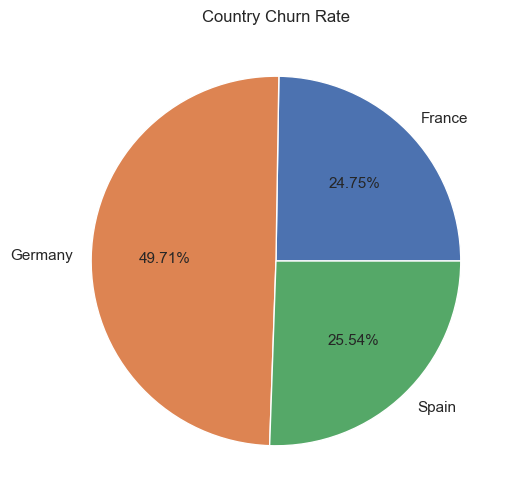

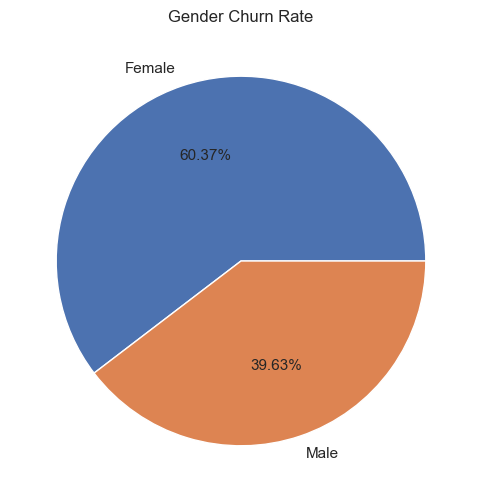

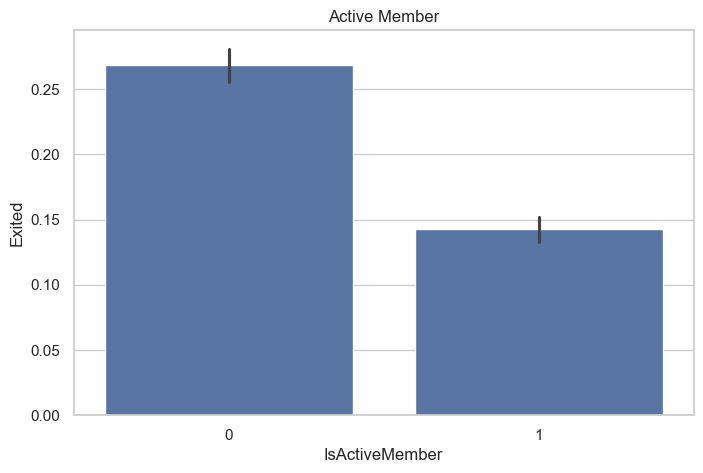

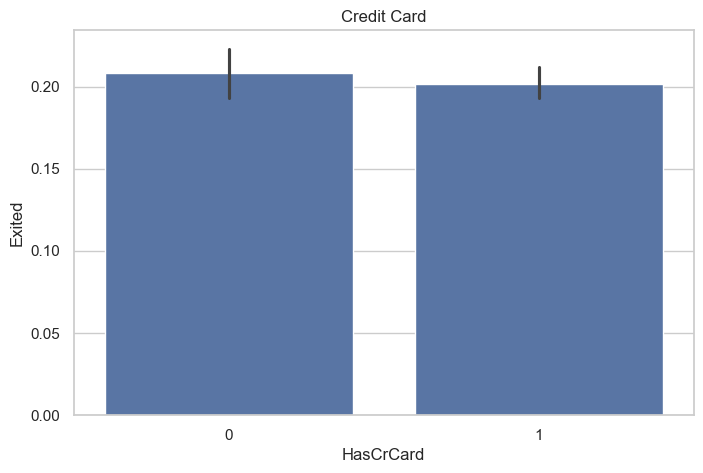

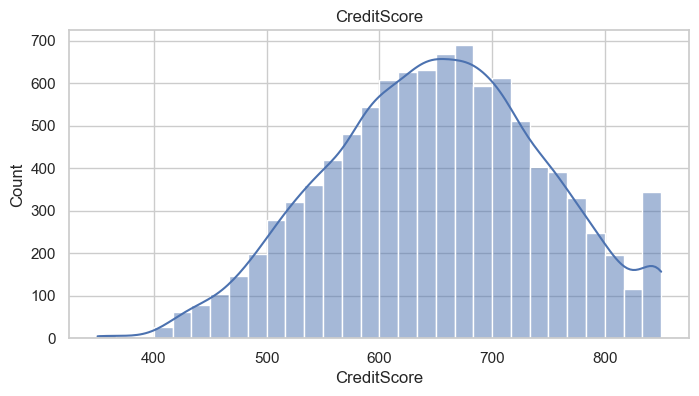

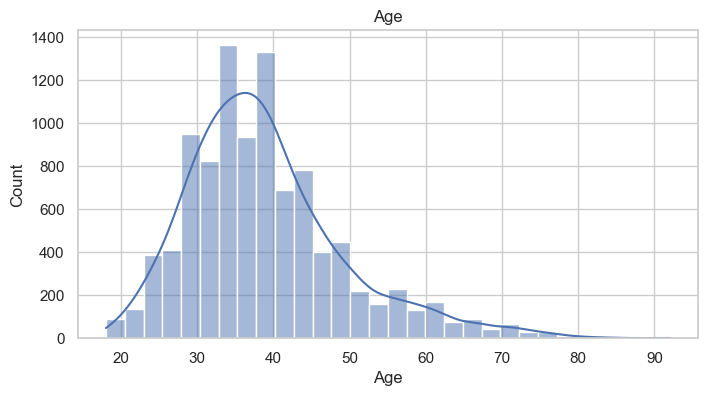

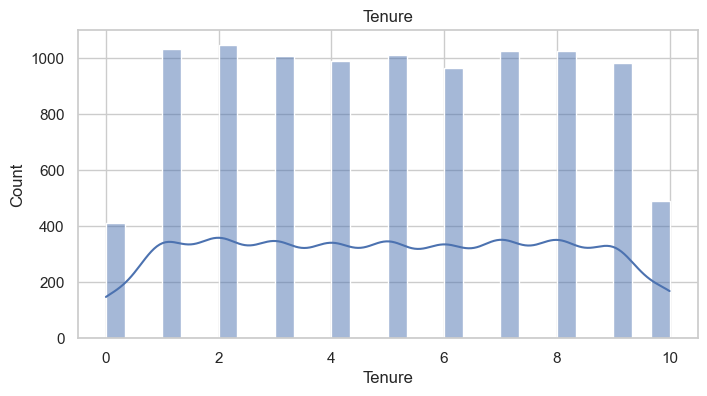

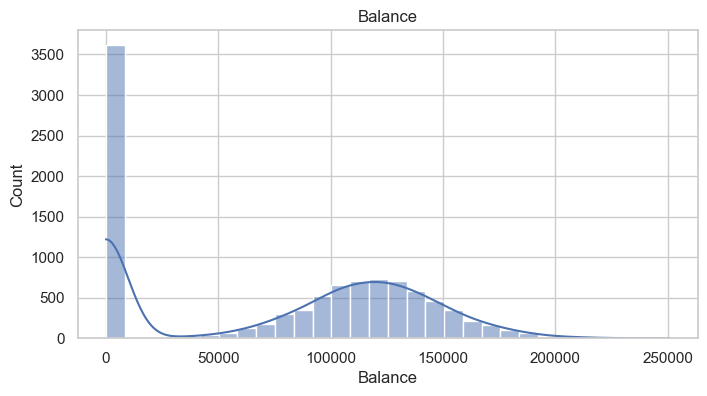

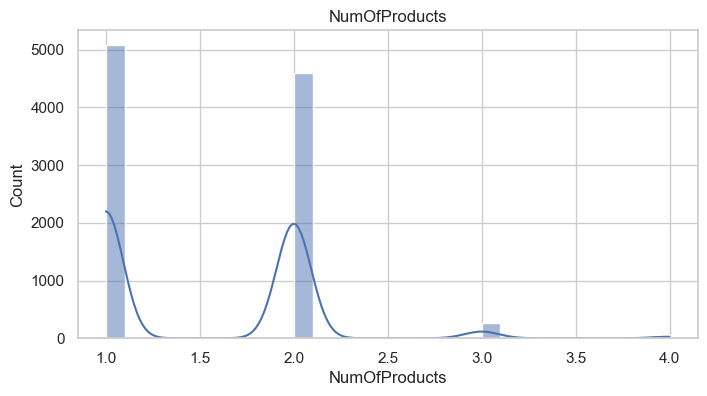

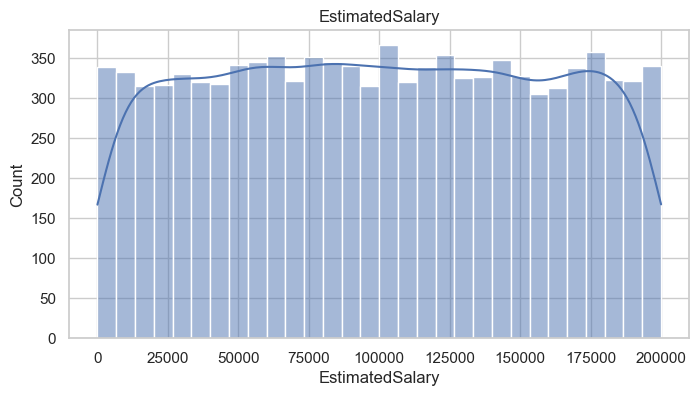

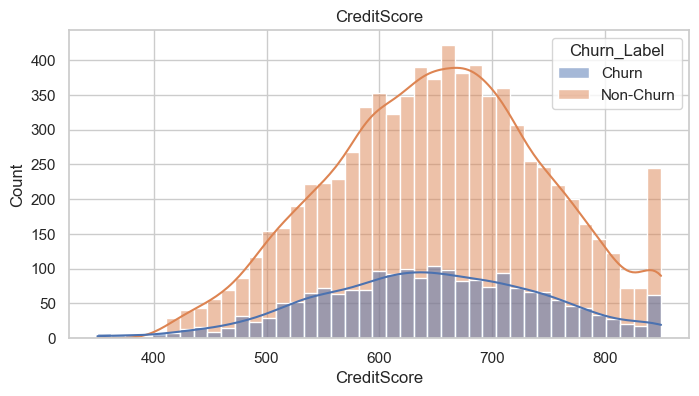

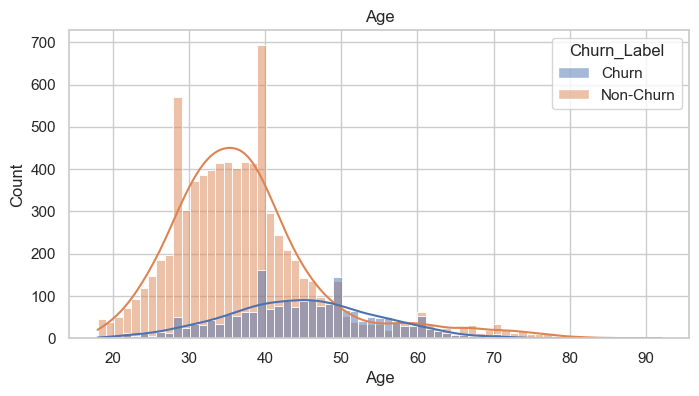

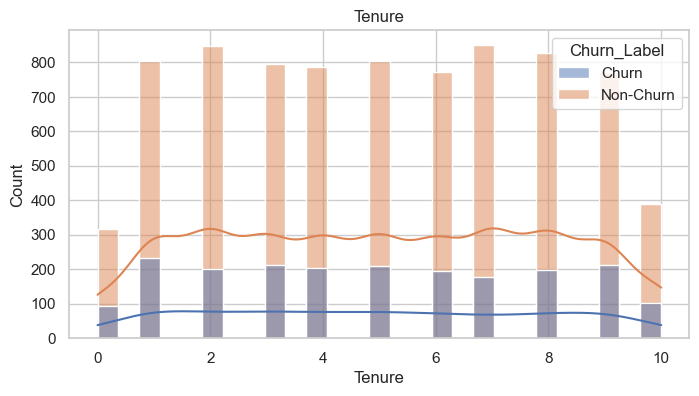

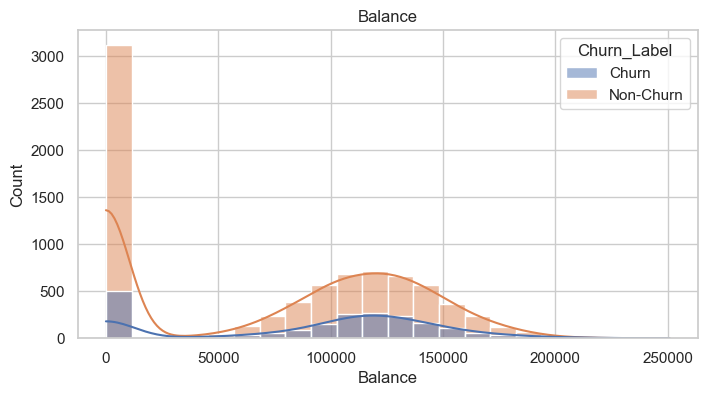

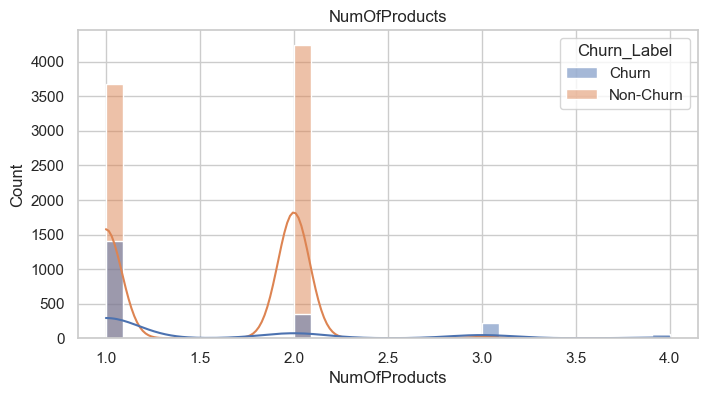

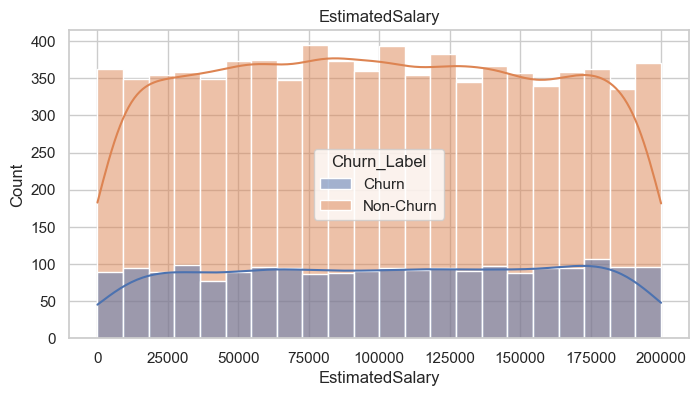

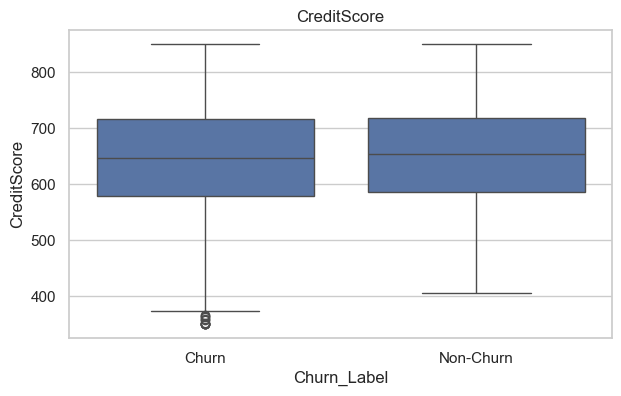

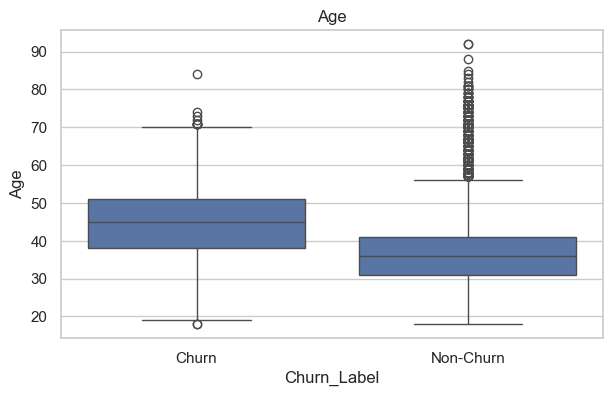

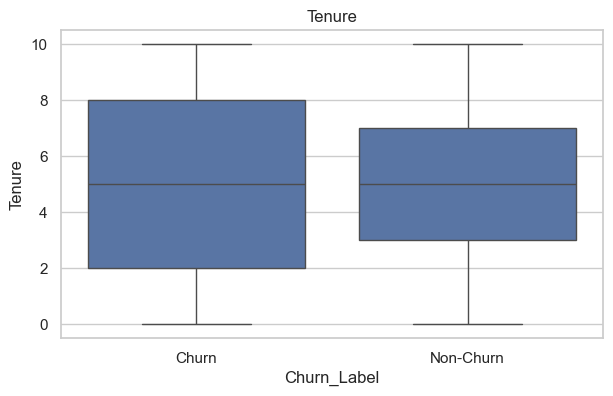

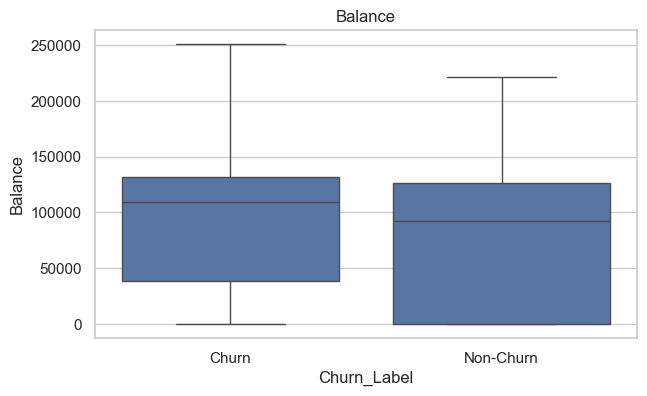

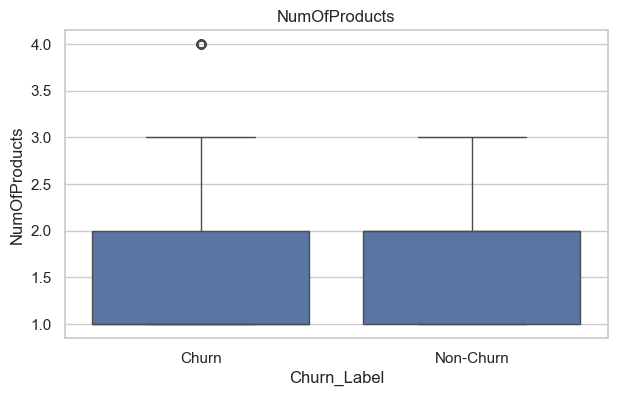

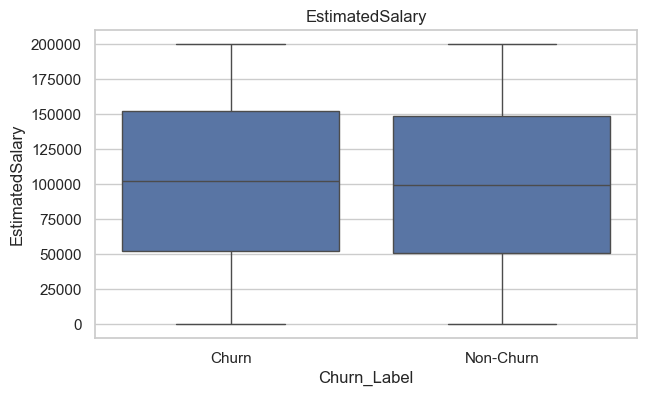

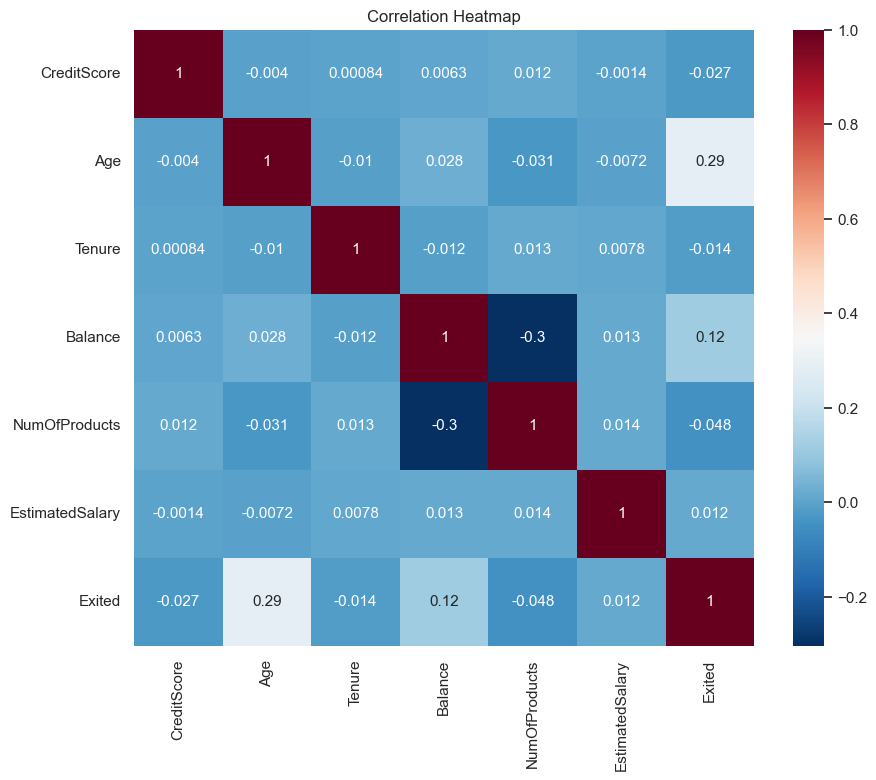

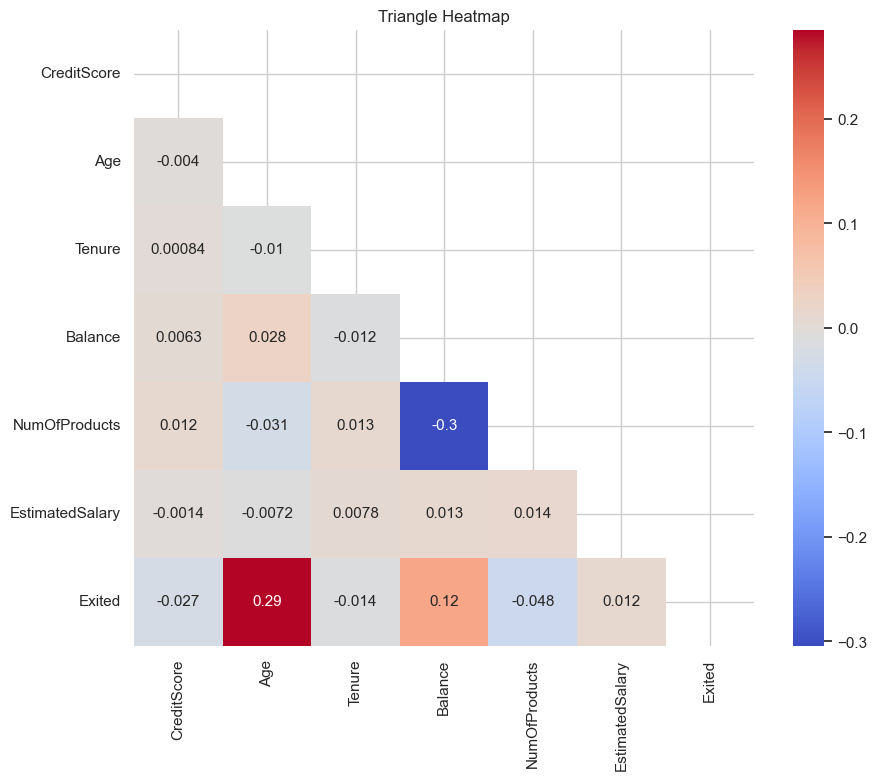

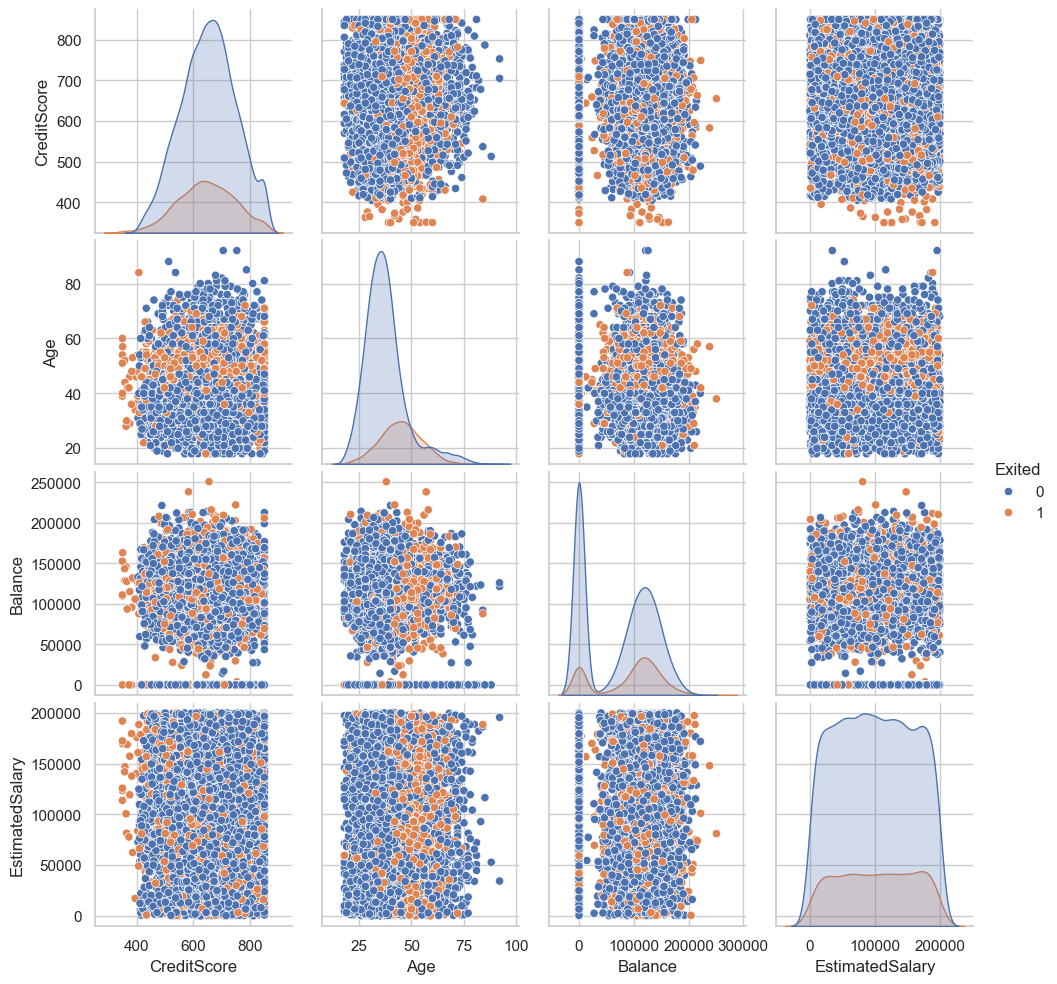

In [40]:
if __name__ == "__main__":

    eda = EDAAnalysis(df)

    analysis = [

        eda.dataset_info,
        eda.missing_value,
        eda.descriptive,
        eda.churn_summary,

        lambda: eda.summary_table("Geography"),
        lambda: eda.summary_table("Gender"),
        lambda: eda.summary_table("IsActiveMember"),
        lambda: eda.summary_table("HasCrCard"),
        lambda: eda.summary_table("NumOfProducts")

    ]

    for func in analysis:
        func()

    visual = Visualization(df)

    visuals = [

        visual.overall_pie,
        visual.pie_country,
        visual.pie_gender,
        visual.bar_active,
        visual.bar_card,
        visual.distribution,
        visual.distribution_churn,
        visual.boxplot,
        visual.heatmap,
        visual.triangle_heatmap,
        visual.pairplot

    ]

    for graph in visuals:
        graph()

# MODEL REGRESI LOGISTIK

## Import Library untuk Prapemrosesan dan Pemodelan

### Deskripsi
Cell ini digunakan untuk mengimpor seluruh library yang diperlukan pada tahap prapemrosesan data (*data preprocessing*), pembangunan model klasifikasi, evaluasi performa model, penanganan ketidakseimbangan kelas (*class imbalance*), serta visualisasi hasil analisis. Seluruh library yang diimpor akan digunakan pada proses pembagian data, standardisasi fitur, pelatihan model Logistic Regression, hingga evaluasi kinerja model menggunakan berbagai metrik klasifikasi.

### Tujuan
- Mengimpor **Pandas** dan **NumPy** untuk manipulasi serta pengolahan data.
- Mengimpor **Matplotlib** dan **Seaborn** untuk membuat visualisasi data dan hasil evaluasi model.
- Mengimpor `train_test_split` untuk membagi dataset menjadi data latih dan data uji.
- Mengimpor `StandardScaler` untuk melakukan standardisasi fitur numerik sebelum proses pelatihan model.
- Mengimpor algoritma **Logistic Regression** sebagai model klasifikasi yang digunakan untuk memprediksi status churn pelanggan.
- Mengimpor berbagai metrik evaluasi, yaitu **Accuracy**, **Precision**, **Recall**, **F1-Score**, **Confusion Matrix**, **Classification Report**, dan **Precision-Recall Curve** untuk mengukur performa model secara komprehensif.
- Mengimpor **RandomOverSampler** untuk mengatasi permasalahan ketidakseimbangan kelas (*class imbalance*) dengan menyeimbangkan jumlah sampel pada setiap kelas.
- Mengatur tema visualisasi menggunakan **Seaborn Whitegrid** agar seluruh grafik memiliki tampilan yang konsisten dan mudah dibaca.

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from imblearn.over_sampling import RandomOverSampler

sns.set_theme(style="whitegrid")

## Mendefinisikan Kelas Dataset

### Deskripsi
Cell ini mendefinisikan kelas **Dataset** yang berfungsi untuk mengelola proses pemuatan dan pemeriksaan awal dataset. Kelas ini menyediakan beberapa metode untuk membaca data, menampilkan informasi dasar dataset, memeriksa keberadaan *missing value*, serta mengetahui distribusi kelas target (*Exited*). Dengan mengelompokkan fungsi-fungsi tersebut ke dalam satu kelas, proses pengelolaan dataset menjadi lebih terstruktur dan mudah digunakan kembali pada berbagai tahap analisis.

### Tujuan
- Membaca dataset dari file berformat **CSV** menggunakan `pd.read_csv()`.
- Menampilkan ukuran dataset (*shape*) sebagai verifikasi bahwa data berhasil dimuat.
- Menampilkan beberapa baris pertama dataset menggunakan metode `head()`.
- Menampilkan informasi struktur dataset, termasuk jumlah data, tipe data, dan kolom yang tersedia.
- Memeriksa jumlah *missing value* pada setiap fitur.
- Menghitung distribusi kelas target (*Exited*) dalam bentuk persentase untuk mengetahui apakah dataset mengalami ketidakseimbangan kelas (*class imbalance*).

In [50]:
class Dataset:

    def __init__(self, filepath):

        self.filepath = filepath
        self.df = None

    def load(self):

        self.df = pd.read_csv(self.filepath)

        print("=== DATASET BERHASIL DIMUAT ===")
        print("Shape :", self.df.shape)

        return self.df

    def head(self, n=5):

        return self.df.head(n)

    def info(self):

        return self.df.info()

    def missing_values(self):

        return self.df.isnull().sum()

    def churn_distribution(self):

        distribution = (
            self.df["Exited"]
            .value_counts(normalize=True)
            *100
        )

        return distribution

## Mendefinisikan Kelas Prapemrosesan Data (Preprocessor)

### Deskripsi
Cell ini mendefinisikan kelas **Preprocessor** yang bertanggung jawab untuk melakukan seluruh tahapan prapemrosesan data sebelum proses pelatihan model machine learning. Tahapan tersebut meliputi pembersihan dataset, transformasi variabel kategorikal, penanganan ketidakseimbangan kelas menggunakan **Random Over Sampling (ROS)**, pembagian dataset menjadi data latih dan data uji, serta standardisasi fitur menggunakan **StandardScaler**.

Seluruh proses prapemrosesan dikemas dalam satu kelas agar alur persiapan data menjadi lebih sistematis, konsisten, dan mudah digunakan kembali.

### Tujuan
- Membersihkan dataset dengan menghapus atribut yang tidak relevan terhadap proses prediksi, yaitu **RowNumber**, **CustomerId**, dan **Surname**.
- Mengubah variabel kategorikal (**Geography** dan **Gender**) menjadi representasi numerik menggunakan **One-Hot Encoding** (`pd.get_dummies()`).
- Mengonversi nilai bertipe **boolean** menjadi tipe **integer** agar kompatibel dengan algoritma machine learning.
- Memisahkan fitur (*X*) dan variabel target (*y*).
- Menyeimbangkan distribusi kelas target menggunakan **Random Over Sampling (ROS)** sehingga jumlah data pada kelas *churn* dan *non-churn* menjadi seimbang.
- Membagi dataset menjadi data latih dan data uji menggunakan **train-test split** dengan proporsi **80% : 20%** serta menerapkan **stratified sampling** untuk mempertahankan proporsi kelas.
- Melakukan standardisasi seluruh fitur numerik menggunakan **StandardScaler** sehingga setiap fitur memiliki skala yang seragam dan proses pelatihan **Logistic Regression** menjadi lebih optimal.
- Menyimpan seluruh hasil prapemrosesan (dataset bersih, data hasil oversampling, data latih, data uji, dan data yang telah distandardisasi) sebagai atribut kelas untuk digunakan pada tahap pemodelan berikutnya.

In [51]:
class Preprocessor:

    def __init__(self, df):

        self.df = df.copy()

        self.X = None
        self.y = None

        self.X_train = None
        self.X_test = None

        self.y_train = None
        self.y_test = None

        self.scaler = None
        self.ros = None

        self.X_train_scaled = None
        self.X_test_scaled = None

    def clean_data(self):

        self.df = self.df.drop(
            columns=[
                "RowNumber",
                "CustomerId",
                "Surname"
            ]
        )

        self.df = pd.get_dummies(
            self.df,
            columns=[
                "Geography",
                "Gender"
            ],
            drop_first=True
        )

        for col in self.df.columns:

            if self.df[col].dtype == bool:

                self.df[col] = self.df[col].astype(int)

        print("="*40)
        print("DATA BERHASIL DIBERSIHKAN")
        print("="*40)

        return self.df


    def random_oversampling(self):

        self.X = self.df.drop(
            "Exited",
            axis=1
        )

        self.y = self.df["Exited"]

        self.ros = RandomOverSampler(

            sampling_strategy=1.0,
            random_state=42

        )

        self.X, self.y = self.ros.fit_resample(

            self.X,
            self.y

        )

        print("="*40)
        print("RANDOM OVER SAMPLING")
        print("="*40)

        print(self.y.value_counts())

        return self.X, self.y


    def split(self):

        (
            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test

        ) = train_test_split(

            self.X,
            self.y,

            test_size=0.20,
            random_state=42,
            stratify=self.y

        )

        print("="*40)
        print("TRAIN TEST SPLIT")
        print("="*40)

        print("\nTraining")
        print(self.y_train.value_counts())

        print("\nTesting")
        print(self.y_test.value_counts())

        return (

            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test

        )


    def scale(self):

        self.scaler = StandardScaler()

        self.X_train_scaled = self.scaler.fit_transform(
            self.X_train
        )

        self.X_test_scaled = self.scaler.transform(
            self.X_test
        )

        print("="*40)
        print("STANDARD SCALER")
        print("="*40)

        return (

            self.X_train_scaled,
            self.X_test_scaled

        )

## Mendefinisikan Model Logistic Regression

### Deskripsi
Cell ini mendefinisikan kelas **LogisticRegressionModel** yang digunakan untuk membangun, melatih, dan mengelola model **Logistic Regression** dalam proses prediksi churn pelanggan. Selain melakukan pelatihan model, kelas ini juga menyediakan fungsi untuk menghasilkan prediksi kelas, probabilitas prediksi, nilai *decision function* (z-score), serta menampilkan koefisien model yang digunakan untuk menginterpretasikan pengaruh setiap fitur terhadap peluang terjadinya churn.

Dengan mengelompokkan seluruh proses pemodelan ke dalam satu kelas, implementasi menjadi lebih modular, mudah dipelihara, dan dapat digunakan kembali pada eksperimen berikutnya.

### Tujuan
- Menginisialisasi model **Logistic Regression** dengan `random_state=42` untuk menghasilkan proses pelatihan yang konsisten serta `max_iter=1000` agar proses optimasi memiliki jumlah iterasi yang memadai.
- Melatih model menggunakan data latih melalui metode `fit()`.
- Menghasilkan prediksi kelas pelanggan (*churn* atau *non-churn*) menggunakan metode `predict()`.
- Menghitung probabilitas pelanggan mengalami churn menggunakan `predict_proba()`.
- Menghasilkan nilai **decision function (z-score)** sebagai skor linear sebelum ditransformasikan ke dalam fungsi sigmoid.
- Menampilkan koefisien setiap fitur beserta nilai kepentingannya (*feature importance*) berdasarkan nilai absolut koefisien.
- Menampilkan nilai **intercept** model yang digunakan dalam persamaan Logistic Regression.
- Menyediakan tabel ringkasan koefisien model untuk memudahkan interpretasi pengaruh masing-masing variabel terhadap prediksi churn.

In [52]:
class LogisticRegressionModel:

    def __init__(self):

        self.model = LogisticRegression(
            random_state=42,
            max_iter=1000
        )

        self.y_pred = None
        self.y_prob = None
        self.z_score = None

    def fit(
        self,
        X_train,
        y_train
    ):

        self.model.fit(
            X_train,
            y_train
        )

        print("="*40)
        print("MODEL BERHASIL DILATIH")
        print("="*40)

        return self

    def predict(
        self,
        X_test
    ):

        self.y_pred = (
            self.model.predict(
                X_test
            )
        )

        self.y_prob = (
            self.model.predict_proba(
                X_test
            )[:,1]
        )

        self.z_score = (
            self.model.decision_function(
                X_test
            )
        )

        return (

            self.y_pred,
            self.y_prob,
            self.z_score

        )

    def coefficients(
        self,
        feature_names
    ):

        coef_df = pd.DataFrame({

            "Feature": feature_names,

            "Coefficient":
            self.model.coef_[0]

        })

        coef_df["Importance"] = (
            coef_df["Coefficient"]
            .abs()
        )

        coef_df = coef_df.sort_values(

            by="Importance",
            ascending=False

        )

        return coef_df

    def intercept(self):

        return self.model.intercept_[0]

    def summary(
        self,
        feature_names
    ):

        summary_df = pd.DataFrame({

            "Feature": feature_names,

            "Coefficient": np.round(
                self.model.coef_[0],
                6
            ),

            "Importance": np.round(
                np.abs(self.model.coef_[0]),
                6
            )

        })

        summary_df = summary_df.sort_values(
            by="Importance",
            ascending=False
        )

        return summary_df

## Mendefinisikan Kelas Evaluasi Model

### Deskripsi
Cell ini mendefinisikan kelas **Evaluation** yang digunakan untuk mengevaluasi performa model **Logistic Regression** setelah proses prediksi selesai dilakukan. Kelas ini menyediakan berbagai metode untuk menghitung metrik evaluasi, menampilkan *classification report*, menghasilkan *confusion matrix*, serta menyusun tabel hasil prediksi yang berisi kelas aktual, hasil prediksi, probabilitas prediksi, dan nilai *decision function* (z-score).

Seluruh metode didefinisikan sebagai **static method** sehingga dapat dipanggil secara langsung tanpa perlu membuat objek dari kelas **Evaluation**.

### Tujuan
- Menghitung metrik evaluasi utama, yaitu **Accuracy**, **Precision**, **Recall**, dan **F1-Score**.
- Menampilkan **Classification Report** yang berisi nilai *precision*, *recall*, *F1-score*, dan *support* untuk setiap kelas.
- Menghasilkan **Confusion Matrix** untuk mengetahui jumlah prediksi yang benar maupun salah pada masing-masing kelas.
- Menyediakan fungsi `evaluate()` yang menggabungkan seluruh hasil evaluasi sehingga lebih praktis untuk digunakan dalam proses analisis performa model.
- Menyusun tabel hasil prediksi yang memuat:
  - Kelas aktual (*Actual*).
  - Kelas hasil prediksi (*Prediction*).
  - Probabilitas prediksi kelas positif (*Probability*).
  - Nilai **decision function (z-score)** sebagai skor linear sebelum transformasi sigmoid.
- Mempermudah analisis performa model serta interpretasi hasil prediksi pada setiap observasi.

In [53]:
class Evaluation:

    @staticmethod
    def metrics(
        y_true,
        y_pred
    ):

        metric_df = pd.DataFrame({

            "Metric":[

                "Accuracy",
                "Precision",
                "Recall",
                "F1 Score"

            ],

            "Value":[

                accuracy_score(
                    y_true,
                    y_pred
                ),

                precision_score(
                    y_true,
                    y_pred
                ),

                recall_score(
                    y_true,
                    y_pred
                ),

                f1_score(
                    y_true,
                    y_pred
                )

            ]

        })

        return metric_df

    @staticmethod
    def report(
        y_true,
        y_pred
    ):

        return classification_report(

            y_true,
            y_pred

        )

    @staticmethod
    def confusion(
        y_true,
        y_pred
    ):

        return confusion_matrix(

            y_true,
            y_pred

        )

    @staticmethod
    def evaluate(
        y_true,
        y_pred
    ):

        print("="*50)
        print("HASIL EVALUASI MODEL")
        print("="*50)

        metric = Evaluation.metrics(
            y_true,
            y_pred
        )

        print(metric)

        print("\n")

        print("="*50)
        print("CLASSIFICATION REPORT")
        print("="*50)

        print(

            Evaluation.report(
                y_true,
                y_pred
            )

        )

        print("="*50)

        cm = Evaluation.confusion(
            y_true,
            y_pred
        )

        return metric, cm

    @staticmethod
    def probability_table(
        y_test,
        y_pred,
        y_prob,
        z_score
    ):

        result = pd.DataFrame({

            "Actual":

            y_test.reset_index(
                drop=True
            ),

            "Prediction":

            y_pred,

            "Probability":

            np.round(
                y_prob,
                4
            ),

            "Z Score":

            np.round(
                z_score,
                4
            )

        })

        return result

## Mendefinisikan Visualisasi Hasil Pemodelan

### Deskripsi
Cell ini mendefinisikan kelas **Visualization** yang digunakan untuk memvisualisasikan hasil proses pemodelan **Logistic Regression**. Visualisasi yang dihasilkan bertujuan untuk membantu memahami karakteristik data, mekanisme kerja model, serta mengevaluasi performa prediksi melalui berbagai jenis grafik. Seluruh visualisasi dikemas dalam metode `show_all()` sehingga seluruh hasil dapat ditampilkan secara berurutan dalam satu kali pemanggilan.

Visualisasi mencakup distribusi data, fungsi sigmoid, hubungan antara *decision score* dan probabilitas prediksi, *confusion matrix*, *precision-recall curve*, koefisien model, serta distribusi probabilitas dan *decision score* hasil prediksi.

### Tujuan
- Menampilkan distribusi jumlah pelanggan **churn** dan **non-churn** menggunakan *count plot*.
- Memvisualisasikan bentuk **fungsi sigmoid** untuk menjelaskan transformasi nilai *decision score* menjadi probabilitas.
- Menampilkan hubungan antara **decision score (z-score)** dan probabilitas prediksi melalui grafik sebar (*scatter plot*).
- Menampilkan **Confusion Matrix** dalam bentuk *heatmap* untuk mempermudah interpretasi hasil klasifikasi.
- Memvisualisasikan **Precision-Recall Curve** sebagai evaluasi kemampuan model dalam membedakan kelas positif pada berbagai nilai ambang (*threshold*).
- Menampilkan koefisien setiap fitur menggunakan diagram batang sehingga pengaruh positif maupun negatif setiap variabel terhadap prediksi churn dapat dianalisis dengan lebih mudah.
- Menampilkan distribusi probabilitas prediksi (*Predicted Probability Distribution*) untuk melihat tingkat keyakinan model terhadap hasil klasifikasi.
- Menampilkan distribusi **Decision Score (Z-Score)** guna memahami penyebaran skor linear yang dihasilkan oleh model sebelum ditransformasikan ke dalam fungsi sigmoid.

In [61]:
class Visualization:

    @staticmethod
    def show_all(
        df,
        z_score,
        y_prob,
        y_test,
        cm,
        coef_df
    ):

        plt.figure(figsize=(7,6))

        sns.countplot(
            data=df,
            x="Exited",
            palette="Blues"
        )

        plt.title(
            "Customer Churn Distribution",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Exited")
        plt.ylabel("Count")

        plt.tight_layout()
        plt.show()

        # 2. Sigmoid Function

        z = np.linspace(-10,10,1000)

        sigmoid = 1/(1+np.exp(-z))

        plt.figure(figsize=(5,5))

        plt.plot(
            z,
            sigmoid,
            linewidth=2
        )

        plt.title(
            "Sigmoid Function",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Z Score")
        plt.ylabel("Probability")

        plt.grid(True)

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(5,5))

        plt.scatter(

            z_score,
            y_prob,

            alpha=0.45

        )

        plt.title(
            "Sigmoid Transformation",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Decision Score (Z)")
        plt.ylabel("Predicted Probability")

        plt.grid(True)

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(5,5))

        sns.heatmap(

            cm,

            annot=True,

            fmt="d",

            cmap="Blues",

            xticklabels=[
                "No Churn",
                "Churn"
            ],

            yticklabels=[
                "No Churn",
                "Churn"
            ]

        )

        plt.title(
            "Confusion Matrix",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")

        plt.tight_layout()
        plt.show()

        precision_curve, recall_curve, _ = (

            precision_recall_curve(

                y_test,
                y_prob

            )

        )

        plt.figure(figsize=(10,5))

        plt.plot(

            recall_curve,
            precision_curve,

            linewidth=2

        )

        plt.title(
            "Precision Recall Curve",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Recall")
        plt.ylabel("Precision")

        plt.grid(True)

        plt.tight_layout()
        plt.show()

        coef_df = coef_df.sort_values(
            by="Coefficient"
        )

        plt.figure(figsize=(10,6))

        sns.barplot(

            data=coef_df,

            x="Coefficient",

            y="Feature",

            palette="viridis"

        )

        plt.axvline(
            x=0,
            color="black",
            linestyle="--"
        )

        plt.title(
            "Feature Coefficients",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Coefficient")
        plt.ylabel("Feature")

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7,5))

        plt.hist(

            y_prob,

            bins=30,

            edgecolor="black"

        )

        plt.title(
            "Predicted Probability Distribution",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Probability")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7,5))

        plt.hist(

            z_score,

            bins=30,

            edgecolor="black"

        )

        plt.title(
            "Decision Score Distribution",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Decision Score")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

## Menjalankan Seluruh Alur Pemodelan Logistic Regression

### Deskripsi
Cell ini merupakan bagian utama (*main program*) yang menjalankan seluruh tahapan analisis secara berurutan, mulai dari pemuatan dataset, prapemrosesan data, pelatihan model **Logistic Regression**, evaluasi performa model, hingga visualisasi hasil prediksi. Setiap tahapan memanfaatkan kelas-kelas yang telah didefinisikan sebelumnya sehingga proses analisis menjadi lebih modular, sistematis, dan mudah dipahami.

Alur yang dijalankan mencakup pemeriksaan dataset, penanganan ketidakseimbangan kelas menggunakan **Random Over Sampling (ROS)**, standardisasi fitur, pelatihan model, interpretasi koefisien model, evaluasi menggunakan berbagai metrik klasifikasi, serta penyajian visualisasi untuk mendukung interpretasi hasil.

### Tujuan
- Memuat dataset dan menampilkan informasi awal berupa:
  - Lima data pertama (*head*).
  - Jumlah *missing value*.
  - Distribusi kelas target (*Exited*).
- Melakukan seluruh tahapan prapemrosesan data, meliputi:
  - Pembersihan dataset.
  - Transformasi variabel kategorikal.
  - Penyeimbangan kelas menggunakan **Random Over Sampling (ROS)**.
  - Pembagian data menjadi data latih dan data uji.
  - Standardisasi fitur menggunakan **StandardScaler**.
- Melatih model **Logistic Regression** menggunakan data latih yang telah distandardisasi.
- Menghasilkan prediksi kelas, probabilitas prediksi, dan **decision score (z-score)** pada data uji.
- Menampilkan informasi model berupa:
  - Nilai **intercept**.
  - Koefisien setiap fitur.
  - Ringkasan koefisien (*model summary*).
- Mengevaluasi performa model menggunakan:
  - Accuracy.
  - Precision.
  - Recall.
  - F1-Score.
  - Classification Report.
  - Confusion Matrix.
- Menampilkan tabel hasil prediksi yang berisi kelas aktual, hasil prediksi, probabilitas prediksi, dan nilai **decision score (z-score)**.
- Menampilkan seluruh visualisasi hasil pemodelan untuk mendukung interpretasi performa model dan pengaruh setiap fitur terhadap prediksi churn.
- Menjalankan seluruh pipeline analisis secara otomatis sehingga keseluruhan proses dapat dieksekusi hanya dengan menjalankan satu cell.

=== DATASET BERHASIL DIMUAT ===
Shape : (10000, 14)

===== 5 DATA PERTAMA =====
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58  

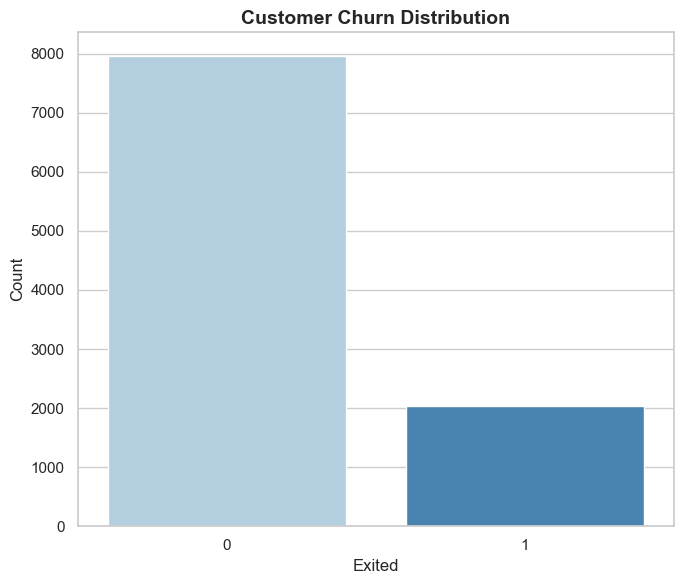

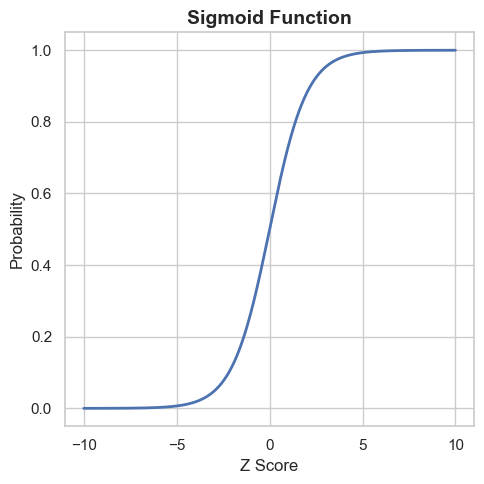

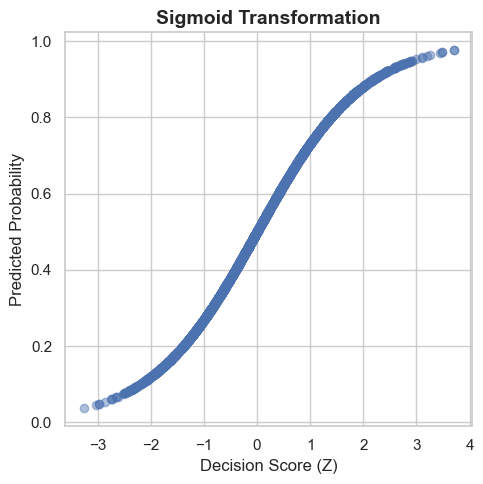

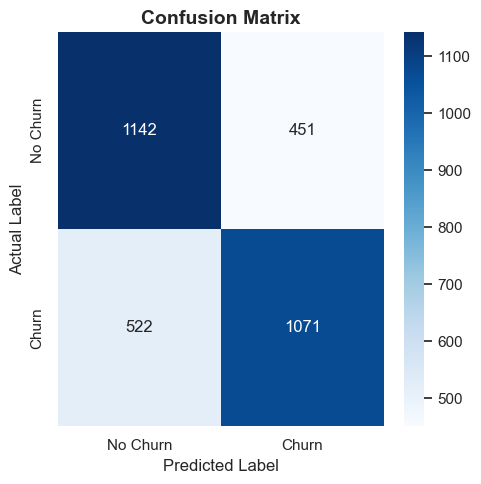

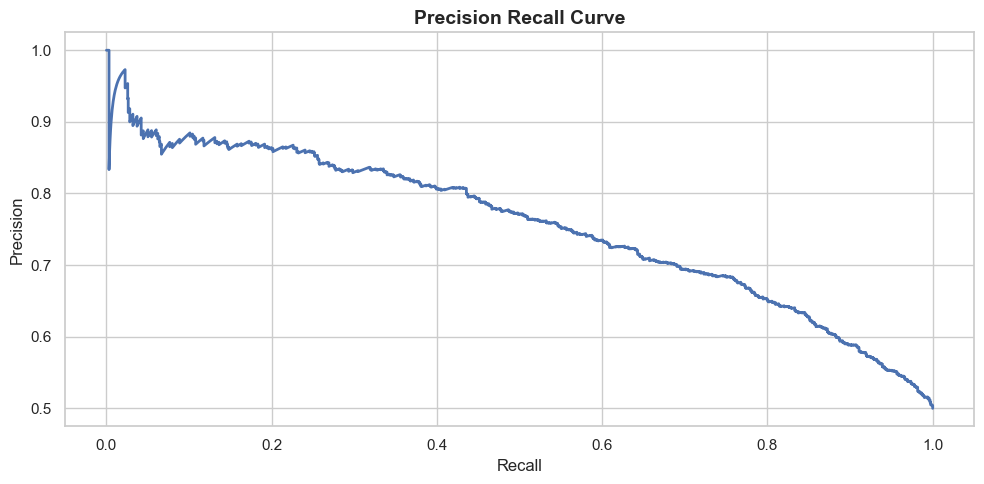

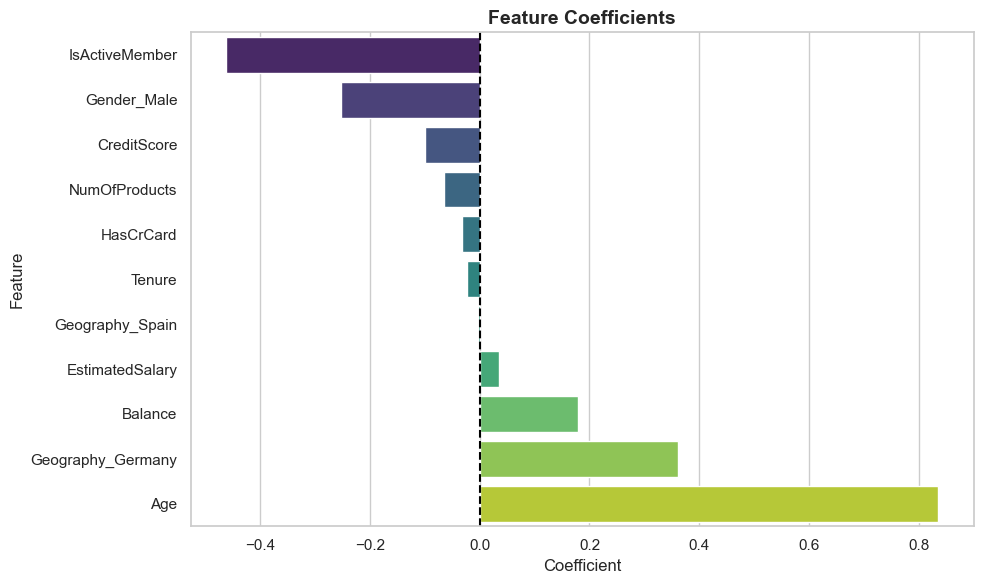

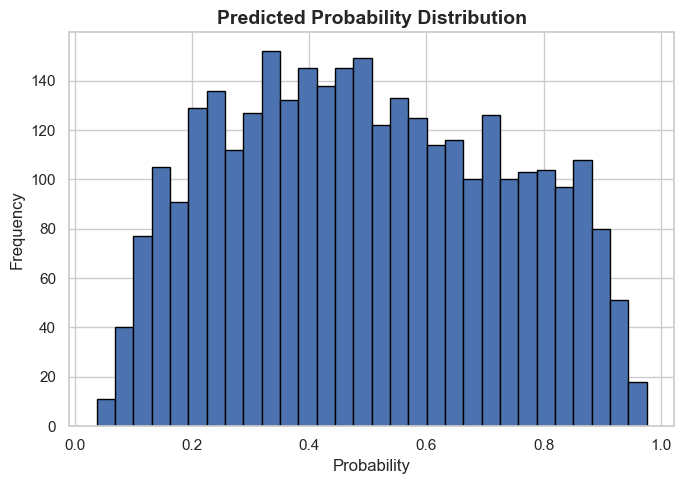

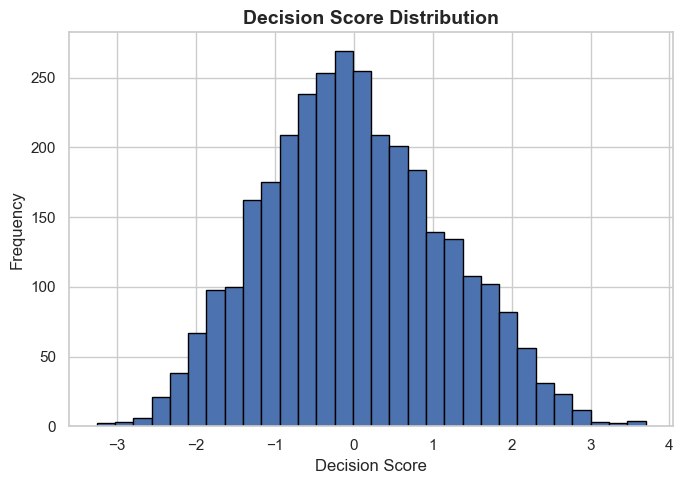



=== PROGRAM SELESAI ===


In [62]:
if __name__ == "__main__":

    # 1. Load Dataset

    dataset = Dataset("Churn_Modelling.csv")

    df = dataset.load()

    print("\n===== 5 DATA PERTAMA =====")
    print(dataset.head())

    print("\n===== MISSING VALUES =====")
    print(dataset.missing_values())

    print("\n===== DISTRIBUSI CHURN (%) =====")
    print(dataset.churn_distribution())

    # 2. Data Preprocessing

    prep = Preprocessor(df)

    prep.clean_data()

    prep.random_oversampling()

    prep.split()


    prep.scale()

    # 3. Training Logistic Regression

    model = LogisticRegressionModel()

    model.fit(
        prep.X_train_scaled,
        prep.y_train
    )

    (
        y_pred,
        y_prob,
        z_score
    ) = model.predict(
        prep.X_test_scaled
    )

    # 4. Informasi Model

    print("\n")
    print("=== INTERCEPT ===")
    print(model.intercept())

    coef_df = model.coefficients(
        prep.X.columns
    )

    summary_df = model.summary(
        prep.X.columns
    )

    print("\n")
    print("=== COEFFICIENT ===")
    print(coef_df)

    print("\n")
    print("=== MODEL SUMMARY ===")
    print(summary_df)

    # 5. Evaluasi

    metric_df = Evaluation.metrics(
        prep.y_test,
        y_pred
    )

    report = Evaluation.report(
        prep.y_test,
        y_pred
    )

    cm = Evaluation.confusion(
        prep.y_test,
        y_pred
    )

    print("\n")
    print("=== METRICS ===")
    print(metric_df)

    print("\n")

    print("=== CLASSIFICATION REPORT ===")
    print(report)

    print("\n")
    print("=== CONFUSION MATRIX ===")
    print(pd.DataFrame(cm))
    probability_df = Evaluation.probability_table(
        prep.y_test,
        y_pred,
        y_prob,
        z_score
    )

    print("\n")
    print("=== PREDICTION RESULT ===")
    print(probability_df.head(20))

    # 6. Visualisasi

    Visualization.show_all(
        prep.df,
        z_score,
        y_prob,
        prep.y_test,
        cm,
        coef_df
    )

    print("\n")
    print("=== PROGRAM SELESAI ===")
    